   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (

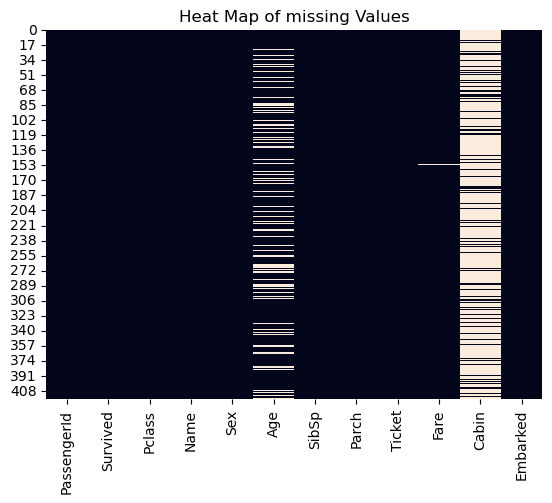

0                  330911
1                  363272
2                  240276
3                  315154
4                 3101298
              ...        
413             A.5. 3236
414              PC 17758
415    SOTON/O.Q. 3101262
416                359309
417                  2668
Name: Ticket, Length: 418, dtype: object


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


Data = pd.read_csv("../data/tested.csv")
print(Data.head())
# print(Data.describe())
print(Data.info())
print(Data.isna().sum())

#visualizing the missing values from the dataset
sns.heatmap(Data.isna(), cbar=False)
plt.title("Heat Map of missing Values")
plt.show()


#dropping the PassengerId and Cabin columns
Data = Data.drop(columns=["PassengerId", "Ticket"])
# feature engineering
Data["Title"] = Data["Name"].str.extract(r",\s*([^\.]+)\.")
Data["Deck"] = Data["Cabin"].str[0]
Data["Deck"].fillna("Missing")
Data = Data.drop(columns=["Name", "Cabin"]) 
# seperating the features according to the data types
num_cols = Data.select_dtypes(include=["int64","float64"]).columns
cat_cols = Data.select_dtypes(include=["object"]).columns

X = Data.drop(columns=["Survived"])
y = Data["Survived"]


for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=Data, x="Survived", y=col)
    plt.title(f"{col} vs Survived")
    plt.xlabel("1 = Survived, 0 = Dead)")
    plt.show()


plt.figure(figsize=(10,9))
corr = Data[num_cols.tolist() + ["Survived"]].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Map")
plt.show()